Dataset Loaded Successfully
(145843, 15)

Training Data: (116674, 7)
Testing Data: (29169, 7)

LINEAR REGRESSION
R2 Score: 0.9417
MAE: 0.31
RMSE: 0.47

DECISION TREE
R2 Score: 1.0
MAE: 0.0
RMSE: 0.0

RANDOM FOREST
R2 Score: 1.0
MAE: 0.0
RMSE: 0.0

MODEL COMPARISON
               Model  R2 Score
0  Linear Regression   0.94166
1      Decision Tree   1.00000
2      Random Forest   1.00000


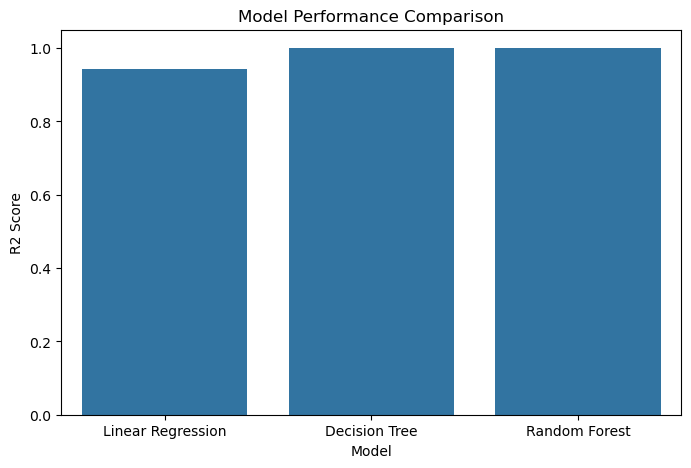

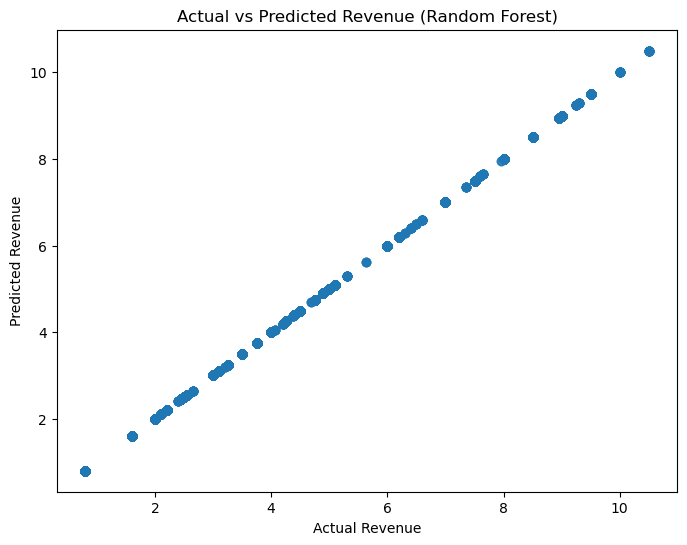

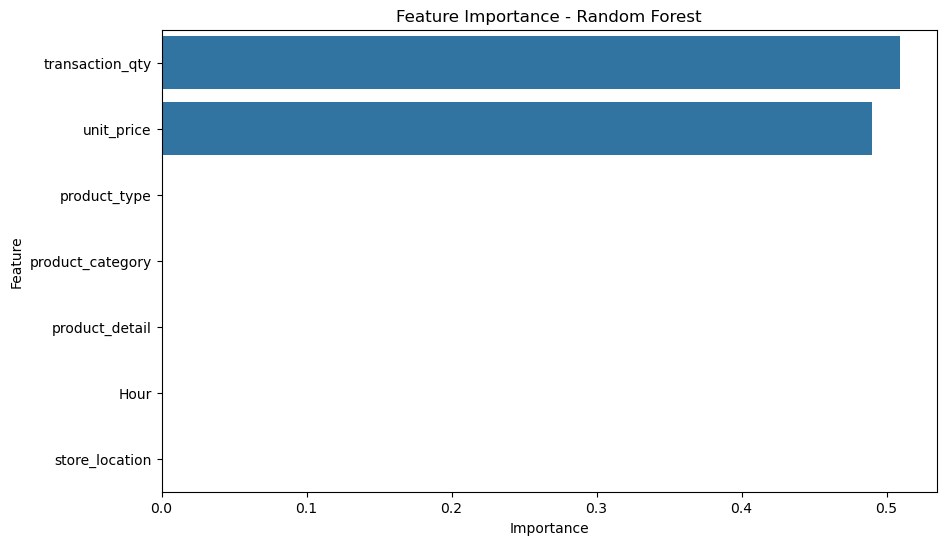


BEST MODEL
Best Model: Decision Tree
Best R2 Score: 1.0


In [3]:
# ==========================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# ==========================================

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_excel(
    r"C:\Users\HP\OneDrive\Desktop\cleaned_coffee_shop_sales.xlsx"
)

print("Dataset Loaded Successfully")
print(df.shape)

# ==========================================
# ENCODE CATEGORICAL VARIABLES
# ==========================================

label_encoder = LabelEncoder()

categorical_columns = [
    'store_location',
    'product_category',
    'product_type',
    'product_detail'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# ==========================================
# FEATURES AND TARGET
# ==========================================

X = df[
    [
        'transaction_qty',
        'unit_price',
        'store_location',
        'product_category',
        'product_type',
        'product_detail',
        'Hour'
    ]
]

y = df['Revenue']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ==========================================
# LINEAR REGRESSION
# ==========================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

print("\n================================")
print("LINEAR REGRESSION")
print("================================")

print("R2 Score:", round(lr_r2, 4))
print("MAE:", round(mean_absolute_error(y_test, lr_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2))

# ==========================================
# DECISION TREE
# ==========================================

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)

print("\n================================")
print("DECISION TREE")
print("================================")

print("R2 Score:", round(dt_r2, 4))
print("MAE:", round(mean_absolute_error(y_test, dt_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, dt_pred)), 2))

# ==========================================
# RANDOM FOREST
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("\n================================")
print("RANDOM FOREST")
print("================================")

print("R2 Score:", round(rf_r2, 4))
print("MAE:", round(mean_absolute_error(y_test, rf_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2))

# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

print("\n================================")
print("MODEL COMPARISON")
print("================================")

print(results)

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("R2 Score")

plt.show()

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title(
    "Actual vs Predicted Revenue (Random Forest)"
)

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance - Random Forest"
)

plt.show()

# ==========================================
# BEST MODEL
# ==========================================

best_model = results.loc[
    results['R2 Score'].idxmax()
]

print("\n================================")
print("BEST MODEL")
print("================================")

print(
    "Best Model:",
    best_model['Model']
)

print(
    "Best R2 Score:",
    round(best_model['R2 Score'], 4)
)

